# Test du modèle type d'image

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

CHEMIN_MODELE = r"C:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\models\type_image_classification_model.keras"
DOSSIER_TEST = r"C:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\data\type_image_dataset_v2_split\test"
IMG_DIMS = 224
model = load_model(CHEMIN_MODELE)
print("Modèle chargé :", CHEMIN_MODELE)
model.summary()

Modèle chargé : C:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\models\type_image_classification_model.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50176)          │       200,704 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    51,381,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,565,643 (623.95 MB)

 Trainable params: 52,141,571 (198.90 MB)

 Non-trainable params: 7,140,928 (27.24 MB)

 Optimizer params: 104,283,144 (397.81 MB)

## 1. Recharger les images de test

In [2]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    DOSSIER_TEST,
    target_size=(IMG_DIMS, IMG_DIMS),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

noms_classes = list(test_gen.class_indices.keys())
print("Classes (dans cet ordre) :", noms_classes)

Found 1412 images belonging to 3 classes.
Classes (dans cet ordre) : ['Autre', 'IRM', 'Radiographie']


## 2. Évaluation chiffrée sur le jeu de test

In [3]:
resultat = model.evaluate(test_gen)
print(dict(zip(model.metrics_names, resultat)))

predictions = model.predict(test_gen)
y_true = test_gen.labels
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=noms_classes))

45/45 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - categorical_accuracy: 1.0000 - loss: 6.2423e-05 - precision: 1.0000 - recall: 1.0000
{'loss': 6.24227977823466e-05, 'compile_metrics': 1.0}
45/45 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step
              precision    recall  f1-score   support

       Autre       1.00      1.00      1.00       412
         IRM       1.00      1.00      1.00       500
Radiographie       1.00      1.00      1.00       500

    accuracy                           1.00      1412
   macro avg       1.00      1.00      1.00      1412
weighted avg       1.00      1.00      1.00      1412



## 3. Matrice de confusion

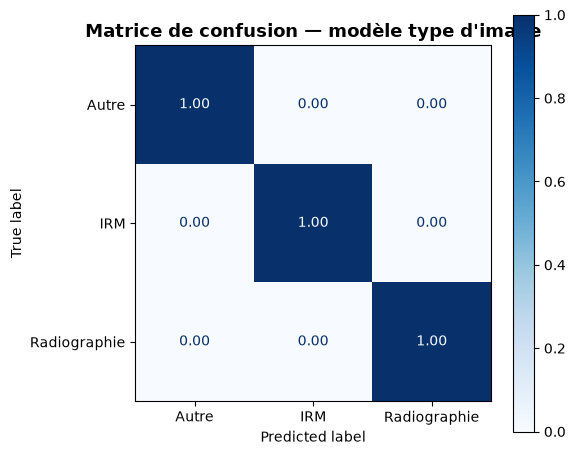

In [4]:
fig, ax = plt.subplots(facecolor="white", figsize=(6, 5), dpi=100)
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=noms_classes,
    include_values=True, normalize="pred", values_format=".2f",
    cmap="Blues", ax=ax
)
plt.title("Matrice de confusion — modèle type d'image", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("matrice_confusion_type_image.png", dpi=150)
plt.show()

## 4. Grad-CAM

In [5]:
def generer_gradcam(model, img_array, nom_derniere_couche_conv="relu"):
    base_model = model.layers[0]
    derniere_couche_conv = base_model.get_layer(nom_derniere_couche_conv)
    modele_conv = tf.keras.models.Model(base_model.input, derniere_couche_conv.output)

    with tf.GradientTape() as tape:
        sortie_conv = modele_conv(img_array, training=False)
        tape.watch(sortie_conv)
        x = sortie_conv
        for couche in model.layers[1:]:
            x = couche(x, training=False)
        predictions = x
        indice_classe = tf.argmax(predictions[0])
        score_classe = predictions[:, indice_classe]

    gradients = tape.gradient(score_classe, sortie_conv)
    gradients_moyennes = tf.reduce_mean(gradients, axis=(0, 1, 2))
    sortie_conv = sortie_conv[0]
    carte_chaleur = sortie_conv @ gradients_moyennes[..., tf.newaxis]
    carte_chaleur = tf.squeeze(carte_chaleur)
    carte_chaleur = tf.maximum(carte_chaleur, 0) / (tf.math.reduce_max(carte_chaleur) + 1e-8)
    return carte_chaleur.numpy(), int(indice_classe.numpy())


def preparer_image(chemin_image, taille=IMG_DIMS):
    image_pil = Image.open(chemin_image).convert("RGB").resize((taille, taille))
    tableau = np.array(image_pil).astype("float32")
    tableau_pretraite = preprocess_input(tableau.copy())
    return image_pil, tableau_pretraite.reshape(1, taille, taille, 3)


def superposer_chaleur(image_pil, carte_chaleur, taille=IMG_DIMS):
    carte_redim = np.array(Image.fromarray(carte_chaleur).resize((taille, taille)))
    colormap = matplotlib.colormaps["jet"]
    carte_couleur = (colormap(carte_redim)[:, :, :3] * 255).astype("uint8")
    return (0.6 * np.array(image_pil) + 0.4 * carte_couleur).astype("uint8")

## 5. Erreurs faites sur les images de test

In [6]:
y_pred_classe = np.argmax(predictions, axis=1)
confiances = np.max(predictions, axis=1)

chemins_fichiers = test_gen.filepaths
erreurs = [
    (chemins_fichiers[i], noms_classes[y_true[i]], noms_classes[y_pred_classe[i]], confiances[i])
    for i in range(len(y_true)) if y_true[i] != y_pred_classe[i]
]
erreurs_triees = sorted(erreurs, key=lambda x: x[3], reverse=True)

print(f"{len(erreurs)} erreurs sur {len(y_true)} images de test ({len(erreurs)/len(y_true):.1%})")

if len(erreurs) == 0:
    print("Aucune erreur sur le jeu de test — rien à afficher.")
else:
    N_A_MONTRER = min(6, len(erreurs_triees))
    fig, axes = plt.subplots(N_A_MONTRER, 2, figsize=(8, 4 * N_A_MONTRER))
    if N_A_MONTRER == 1:
        axes = axes.reshape(1, 2)

    for i, (chemin, vraie_classe, classe_predite, conf) in enumerate(erreurs_triees[:N_A_MONTRER]):
        image_pil, tableau = preparer_image(chemin)
        carte_chaleur, _ = generer_gradcam(model, tableau)
        superposition = superposer_chaleur(image_pil, carte_chaleur)

        axes[i, 0].imshow(image_pil)
        axes[i, 0].set_title(f"Réel : {vraie_classe}")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(superposition)
        axes[i, 1].set_title(f"✗ Prédit : {classe_predite} ({conf:.0%})", color="red")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.savefig("erreurs_confiantes_type_image.png", dpi=150, bbox_inches="tight")
    plt.show()

0 erreurs sur 1412 images de test (0.0%)
Aucune erreur sur le jeu de test — rien à afficher.


## 6. Un exemple détaillé

Image réelle       : Autre
Prédiction modèle  : Autre (100% de confiance)


c:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


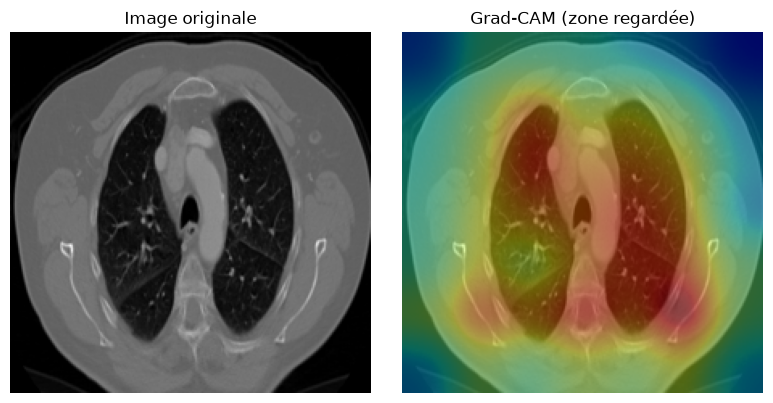

In [7]:
classe_a_tester = noms_classes[0]
dossier_classe = os.path.join(DOSSIER_TEST, classe_a_tester)
nom_image = os.listdir(dossier_classe)[0]
chemin_image = os.path.join(dossier_classe, nom_image)

image_pil, tableau = preparer_image(chemin_image)
proba = model.predict(tableau, verbose=0)[0]
indice_predit = np.argmax(proba)

print(f"Image réelle       : {classe_a_tester}")
print(f"Prédiction modèle  : {noms_classes[indice_predit]} ({proba[indice_predit]:.0%} de confiance)")

carte_chaleur, _ = generer_gradcam(model, tableau)
superposition = superposer_chaleur(image_pil, carte_chaleur)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_pil)
plt.title("Image originale")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(superposition)
plt.title("Grad-CAM (zone regardée)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Grille de plusieurs exemples (une image par classe)

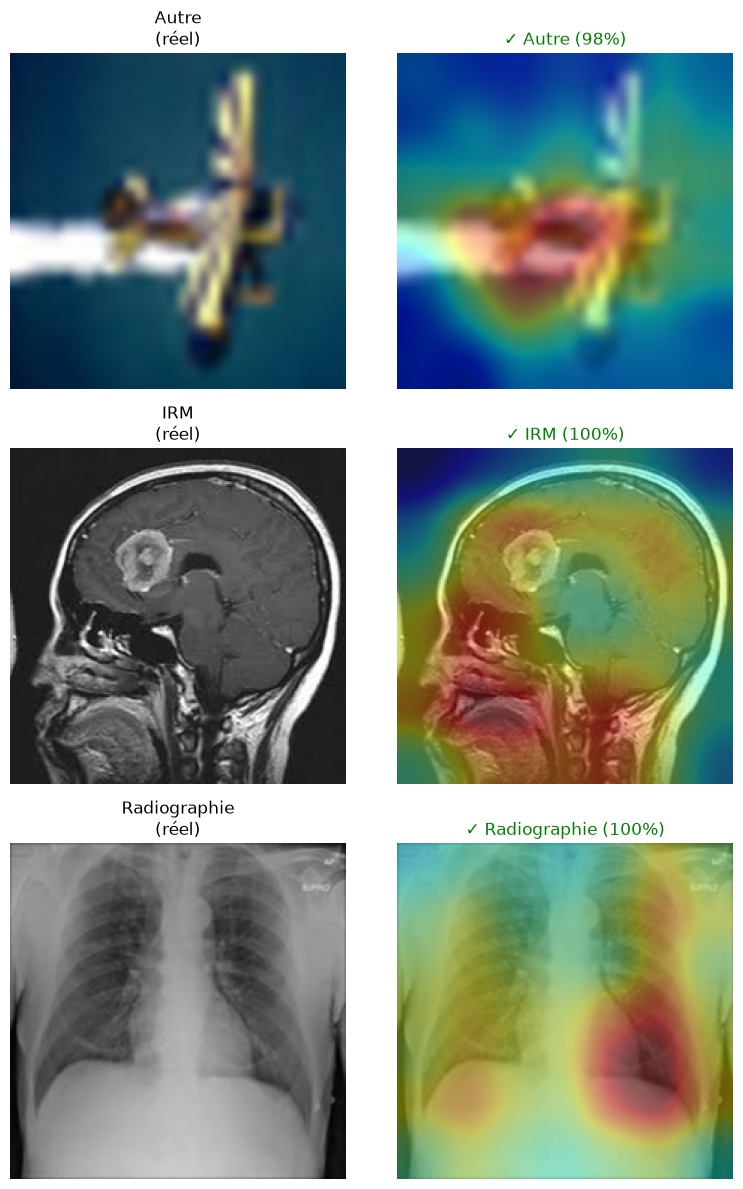

In [8]:
import random
random.seed(42)

fig, axes = plt.subplots(len(noms_classes), 2, figsize=(8, 4 * len(noms_classes)))

for i, classe in enumerate(noms_classes):
    dossier_classe = os.path.join(DOSSIER_TEST, classe)
    nom_image = random.choice(os.listdir(dossier_classe))
    chemin_image = os.path.join(dossier_classe, nom_image)

    image_pil, tableau = preparer_image(chemin_image)
    proba = model.predict(tableau, verbose=0)[0]
    indice_predit = np.argmax(proba)
    prediction = noms_classes[indice_predit]
    confiance = proba[indice_predit]
    correct = (prediction == classe)

    carte_chaleur, _ = generer_gradcam(model, tableau)
    superposition = superposer_chaleur(image_pil, carte_chaleur)

    axes[i, 0].imshow(image_pil)
    axes[i, 0].set_title(f"{classe}\n(réel)")
    axes[i, 0].axis("off")

    couleur = "green" if correct else "red"
    symbole = "✓" if correct else "✗"
    axes[i, 1].imshow(superposition)
    axes[i, 1].set_title(f"{symbole} {prediction} ({confiance:.0%})", color=couleur)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("grille_gradcam_type_image.png", dpi=150, bbox_inches="tight")
plt.show()